Device : cuda


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


✅ CLIP chargé — 151,277,313 paramètres
Images      : 5000
Annotations : 25014
Paires positives : 25014


Encodage images: 100%|██████████| 40/40 [00:47<00:00,  1.20s/it]


Embeddings : torch.Size([5000, 512])
Construction des paires partielles / négatives...
  Batch 1/10 ✅
  Batch 2/10 ✅
  Batch 3/10 ✅
  Batch 4/10 ✅
  Batch 5/10 ✅
  Batch 6/10 ✅
  Batch 7/10 ✅
  Batch 8/10 ✅
  Batch 9/10 ✅
  Batch 10/10 ✅
Partielles : 5000 | Négatives : 5000
Total paires :
score
1.0    25014
0.0     5000
0.5     5000
Name: count, dtype: int64
Train : 28,011 paires (438 batches)
Val   : 7,003 paires (110 batches)


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


trainable params: 1,474,560 || all params: 152,751,873 || trainable%: 0.9653
[LoRA] Ep 01 │ loss 0.0534→0.0301 │ Pearson 0.788→0.883 │ Acc 79.1%→85.3% │ R@1 I→T 0.107  T→I 0.090 ✅
[LoRA] Ep 02 │ loss 0.0281→0.0286 │ Pearson 0.892→0.888 │ Acc 85.6%→85.5% │ R@1 I→T 0.115  T→I 0.095 ✅
[LoRA] Ep 03 │ loss 0.0259→0.0287 │ Pearson 0.901→0.889 │ Acc 86.1%→85.6% │ R@1 I→T 0.115  T→I 0.091 ✅
[LoRA] Ep 04 │ loss 0.0241→0.0278 │ Pearson 0.909→0.891 │ Acc 86.6%→85.9% │ R@1 I→T 0.104  T→I 0.089 ✅
[LoRA] Ep 05 │ loss 0.0225→0.0283 │ Pearson 0.915→0.892 │ Acc 87.3%→86.2% │ R@1 I→T 0.107  T→I 0.082 ✅
[LoRA] Ep 06 │ loss 0.0210→0.0279 │ Pearson 0.922→0.893 │ Acc 88.0%→86.2% │ R@1 I→T 0.092  T→I 0.079 ✅
[LoRA] Ep 07 │ loss 0.0197→0.0284 │ Pearson 0.928→0.891 │ Acc 88.6%→86.3% │ R@1 I→T 0.093  T→I 0.075
[LoRA] Ep 08 │ loss 0.0184→0.0285 │ Pearson 0.933→0.889 │ Acc 89.2%→86.0% │ R@1 I→T 0.084  T→I 0.069
[LoRA] Ep 09 │ loss 0.0171→0.0292 │ Pearson 0.938→0.888 │ Acc 89.9%→86.2% │ R@1 I→T 0.073  T→I 0.065
[L

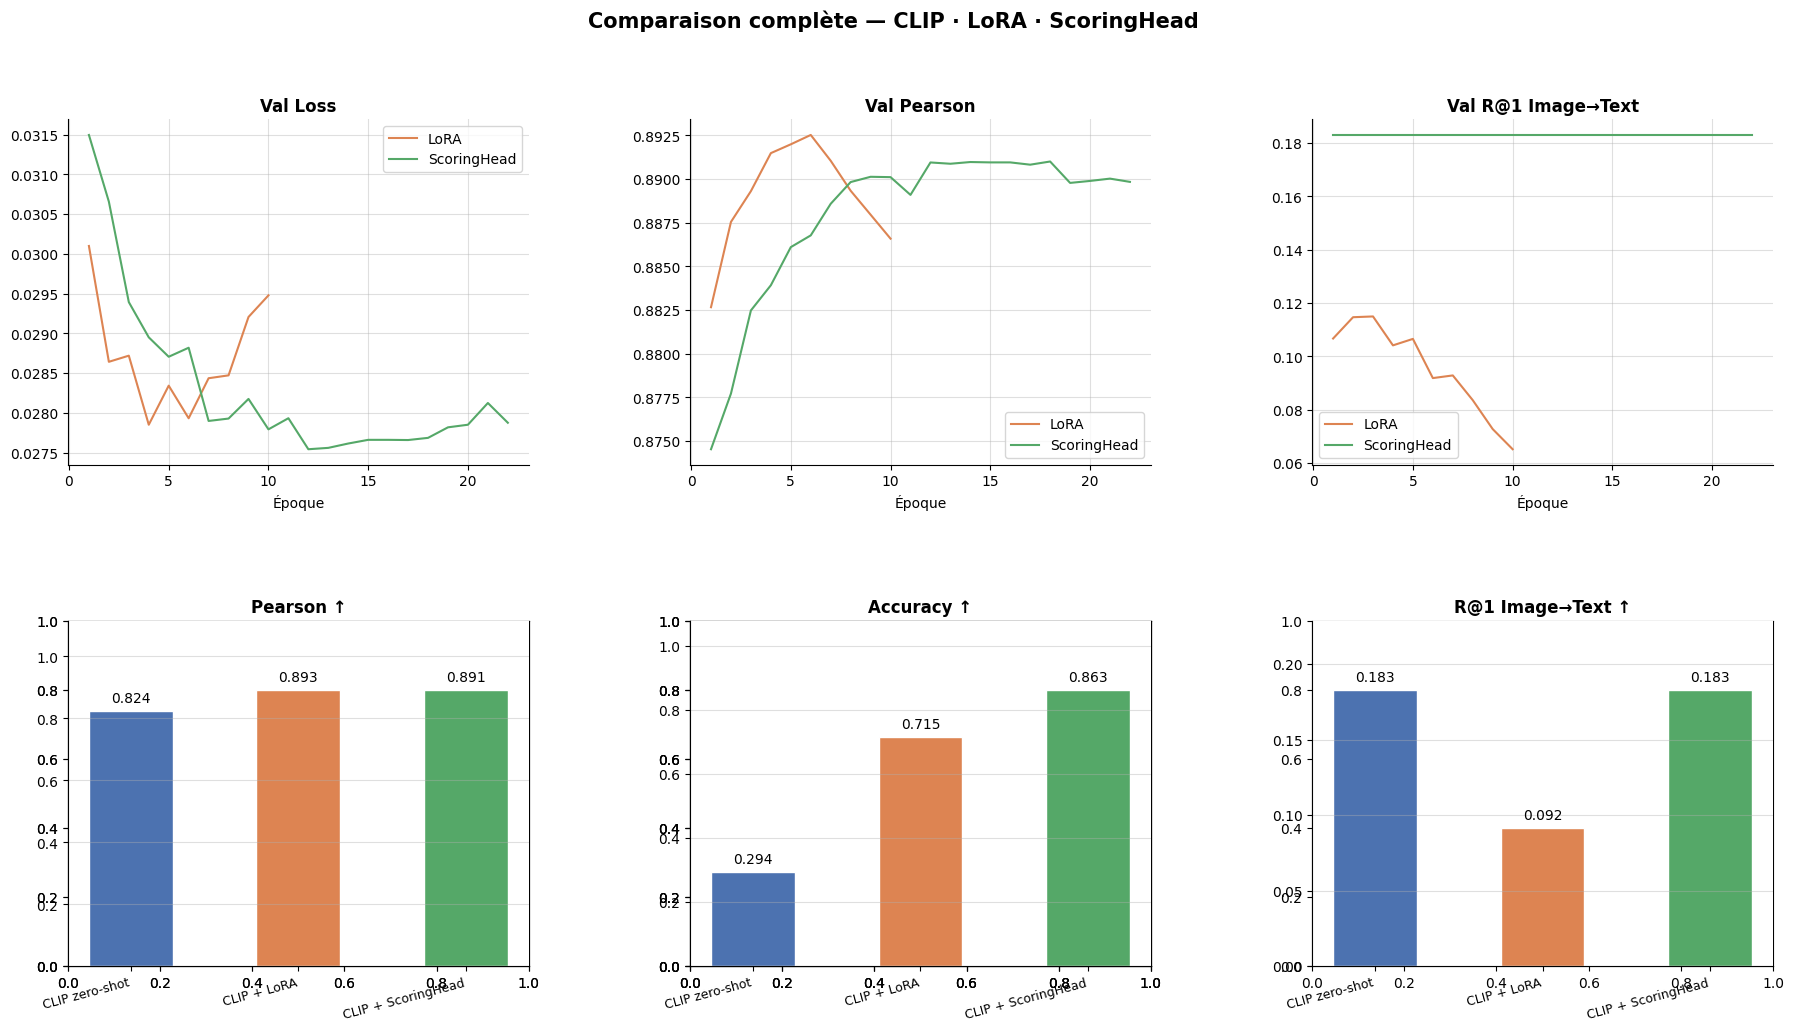

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# 0. INSTALLATION & IMPORTS
# ══════════════════════════════════════════════════════════════════════════════
!pip install open-clip-torch ftfy peft -q

import os, json, random, copy
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import open_clip
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")


# ══════════════════════════════════════════════════════════════════════════════
# 1. CHARGEMENT CLIP (base — conservé intact pour la comparaison finale)
# ══════════════════════════════════════════════════════════════════════════════
clip_base, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
tokenizer = open_clip.get_tokenizer("ViT-B-32")
clip_base  = clip_base.to(device)
clip_base.eval()
for p in clip_base.parameters():          # restera toujours frozen
    p.requires_grad_(False)

print(f"✅ CLIP chargé — {sum(p.numel() for p in clip_base.parameters()):,} paramètres")


# ══════════════════════════════════════════════════════════════════════════════
# 2. CHARGEMENT DES ANNOTATIONS COCO
# ══════════════════════════════════════════════════════════════════════════════
ANN_PATH = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/captions_val2017.json"
IMG_DIR  = "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017"

with open(ANN_PATH) as f:
    data = json.load(f)

print(f"Images      : {len(data['images'])}")
print(f"Annotations : {len(data['annotations'])}")


# ══════════════════════════════════════════════════════════════════════════════
# 3. CONSTRUCTION DES PAIRES POSITIVES
# ══════════════════════════════════════════════════════════════════════════════
id_to_filename = {img["id"]: img["file_name"] for img in data["images"]}

records = [
    {
        "image_id"   : ann["image_id"],
        "image_path" : os.path.join(IMG_DIR, id_to_filename[ann["image_id"]]),
        "caption"    : ann["caption"],
        "score"      : 1.0,
    }
    for ann in data["annotations"]
    if ann["image_id"] in id_to_filename
]

df_positive = pd.DataFrame(records)
print(f"Paires positives : {len(df_positive)}")


# ══════════════════════════════════════════════════════════════════════════════
# 4. ENCODAGE DE TOUTES LES IMAGES (pour construire les négatifs/partiels)
# ══════════════════════════════════════════════════════════════════════════════
class ImageOnlyDataset(Dataset):
    def __init__(self, paths, preprocess):
        self.paths      = paths
        self.preprocess = preprocess

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.preprocess(img), self.paths[idx]


unique_images = df_positive["image_path"].unique().tolist()
img_loader    = DataLoader(
    ImageOnlyDataset(unique_images, preprocess_val),
    batch_size=128, shuffle=False, num_workers=2,
)

all_image_features, all_image_paths = [], []
clip_base.eval()
with torch.no_grad():
    for imgs, paths in tqdm(img_loader, desc="Encodage images"):
        feats = F.normalize(clip_base.encode_image(imgs.to(device)).float(), dim=-1)
        all_image_features.append(feats.cpu())
        all_image_paths.extend(paths)

all_image_features = torch.cat(all_image_features, dim=0)   # (N, 512)
print(f"Embeddings : {all_image_features.shape}")


# ══════════════════════════════════════════════════════════════════════════════
# 5. CONSTRUCTION DES PAIRES PARTIELLES (0.5) ET NÉGATIVES (0.0)
# ══════════════════════════════════════════════════════════════════════════════
path_to_idx    = {p: i for i, p in enumerate(all_image_paths)}
id_to_captions = df_positive.groupby("image_id")["caption"].apply(list).to_dict()
id_to_path     = (
    df_positive.drop_duplicates("image_id")
               .set_index("image_id")["image_path"]
               .to_dict()
)

unique_ids   = df_positive["image_id"].unique().tolist()
unique_paths = [id_to_path[uid] for uid in unique_ids]

records_partial, records_negative = [], []
BATCH = 500

print("Construction des paires partielles / négatives...")
for i in range(0, len(unique_paths), BATCH):
    batch_paths   = unique_paths[i : i + BATCH]
    batch_ids     = unique_ids[i : i + BATCH]
    batch_indices = [path_to_idx[p] for p in batch_paths]
    batch_feats   = all_image_features[batch_indices]           # (B, 512)
    sim_matrix    = batch_feats @ all_image_features.T          # (B, N)

    for j, (path, img_id) in enumerate(zip(batch_paths, batch_ids)):
        sims          = sim_matrix[j].clone()
        self_idx      = path_to_idx[path]
        sims[self_idx] = -1.0

        # Partiel : top-5 images les plus proches (score 0.5)
        top5_idx  = sims.topk(5).indices.tolist()
        top5_path = all_image_paths[random.choice(top5_idx)]
        top5_ids  = df_positive.loc[
            df_positive["image_path"] == top5_path, "image_id"
        ].values
        if len(top5_ids):
            records_partial.append({
                "image_id"   : img_id,
                "image_path" : path,
                "caption"    : random.choice(id_to_captions[top5_ids[0]]),
                "score"      : 0.5,
            })

        # Négatif : image la plus lointaine (score 0.0)
        sims[self_idx] = 1.0
        bot_idx  = sims.topk(1, largest=False).indices.item()
        bot_path = all_image_paths[bot_idx]
        bot_ids  = df_positive.loc[
            df_positive["image_path"] == bot_path, "image_id"
        ].values
        if len(bot_ids):
            records_negative.append({
                "image_id"   : img_id,
                "image_path" : path,
                "caption"    : random.choice(id_to_captions[bot_ids[0]]),
                "score"      : 0.0,
            })

    print(f"  Batch {i//BATCH + 1}/{(len(unique_paths)-1)//BATCH + 1} ✅")

df_partial  = pd.DataFrame(records_partial)
df_negative = pd.DataFrame(records_negative)
print(f"Partielles : {len(df_partial)} | Négatives : {len(df_negative)}")


# ══════════════════════════════════════════════════════════════════════════════
# 6. FUSION & SPLIT TRAIN / VAL
# ══════════════════════════════════════════════════════════════════════════════
df_all = (
    pd.concat([df_positive, df_partial, df_negative], ignore_index=True)
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)
print(f"Total paires :\n{df_all['score'].value_counts()}")

df_train, df_val = train_test_split(
    df_all, test_size=0.2, random_state=42, stratify=df_all["score"]
)


# ══════════════════════════════════════════════════════════════════════════════
# 7. DATASET & DATALOADERS
# ══════════════════════════════════════════════════════════════════════════════
class PairDataset(Dataset):
    """Paires (image, caption, score) pour le fine-tuning."""

    def __init__(self, df: pd.DataFrame, preprocess, tokenizer):
        self.df         = df.reset_index(drop=True)
        self.preprocess = preprocess
        self.tokenizer  = tokenizer

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        image  = Image.open(row["image_path"]).convert("RGB")
        image  = self.preprocess(image)                     # (3, 224, 224)
        tokens = self.tokenizer([row["caption"]])[0]        # (77,)
        score  = torch.tensor(row["score"], dtype=torch.float32)
        return image, tokens, score


train_dataset = PairDataset(df_train, preprocess_val, tokenizer)
val_dataset   = PairDataset(df_val,   preprocess_val, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train : {len(train_dataset):,} paires ({len(train_loader)} batches)")
print(f"Val   : {len(val_dataset):,} paires ({len(val_loader)} batches)")


# ══════════════════════════════════════════════════════════════════════════════
# 8. MÉTRIQUES PARTAGÉES
# ══════════════════════════════════════════════════════════════════════════════
def threshold_accuracy(preds: np.ndarray, labels: np.ndarray) -> float:
    pred_class = np.where(preds > 0.66, 1.0, np.where(preds > 0.33, 0.5, 0.0))
    return float((pred_class == labels).mean())


def compute_recall_at_k(
    img_feats: torch.Tensor, txt_feats: torch.Tensor, k: int = 1
) -> tuple[float, float]:
    sim    = img_feats @ txt_feats.T
    N      = sim.size(0)
    labels = torch.arange(N)
    r_i2t  = (sim.topk(k, dim=1).indices == labels.unsqueeze(1)).any(dim=1).float().mean().item()
    r_t2i  = (sim.T.topk(k, dim=1).indices == labels.unsqueeze(1)).any(dim=1).float().mean().item()
    return r_i2t, r_t2i


def compute_metrics(preds: np.ndarray, labels: np.ndarray) -> dict:
    mse = mean_squared_error(labels, preds)
    return {
        "mse"     : mse,
        "rmse"    : float(np.sqrt(mse)),
        "pearson" : float(pearsonr(labels, preds)[0]),
        "acc"     : threshold_accuracy(preds, labels),
    }


# ══════════════════════════════════════════════════════════════════════════════
# 9. SCORING HEAD
# ══════════════════════════════════════════════════════════════════════════════
class ScoringHead(nn.Module):
    """
    Prédit un score de compatibilité image-texte ∈ (0, 1).

    Fusionne trois signaux :
        img_feat            — contexte visuel global
        txt_feat            — contexte textuel global
        img_feat * txt_feat — interaction locale élément-wise
    """

    def __init__(self, embed_dim: int = 512, hidden: int = 256, dropout: float = 0.3):
        super().__init__()
        self.embed_dim = embed_dim
        self.net = nn.Sequential(
            nn.Linear(embed_dim * 3, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 4),
            nn.LayerNorm(hidden // 4),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden // 4, 1),
            nn.Sigmoid(),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, img_feat: torch.Tensor, txt_feat: torch.Tensor) -> torch.Tensor:
        """
        Args:
            img_feat : (B, D) L2-normalisé
            txt_feat : (B, D) L2-normalisé
        Returns:
            score    : (B,) ∈ (0, 1)
        """
        fused = torch.cat([img_feat, txt_feat, img_feat * txt_feat], dim=-1)
        return self.net(fused).squeeze(-1)

    def extra_repr(self) -> str:
        return f"embed_dim={self.embed_dim}, params={sum(p.numel() for p in self.parameters()):,}"


# ══════════════════════════════════════════════════════════════════════════════
# 10. MODÈLE CLIP + LoRA  (copie indépendante de clip_base)
# ══════════════════════════════════════════════════════════════════════════════
import copy as _copy

clip_lora, _, _ = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
clip_lora = clip_lora.to(device)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    target_modules=["attn.in_proj", "attn.out_proj", "mlp.c_fc", "mlp.c_proj"],
    task_type=TaskType.FEATURE_EXTRACTION,
)
clip_lora = get_peft_model(clip_lora, lora_config)
clip_lora.print_trainable_parameters()
clip_lora = clip_lora.to(device)


# ══════════════════════════════════════════════════════════════════════════════
# 11. FONCTIONS D'ENTRAÎNEMENT GÉNÉRIQUES
# ══════════════════════════════════════════════════════════════════════════════
def _forward_pass(clip_model, scoring_head, images, tokens):
    """Embeddings + score (avec ou sans tête)."""
    img_feat = F.normalize(clip_model.encode_image(images).float(), dim=-1)
    txt_feat = F.normalize(clip_model.encode_text(tokens).float(),  dim=-1)
    if scoring_head is not None:
        preds = scoring_head(img_feat, txt_feat)
    else:
        preds = (img_feat * txt_feat).sum(dim=-1)          # cosine similarity brute
    return img_feat, txt_feat, preds


def run_epoch(clip_model, scoring_head, loader, optimizer, loss_fn, train: bool):
    clip_model.train(train)
    if scoring_head is not None:
        scoring_head.train(train)

    total_loss = 0.0
    all_preds, all_labels             = [], []
    all_img_feats, all_txt_feats      = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, tokens, scores in loader:
            images, tokens, scores = images.to(device), tokens.to(device), scores.to(device)
            img_feat, txt_feat, preds = _forward_pass(clip_model, scoring_head, images, tokens)
            loss = loss_fn(preds, scores)

            if train and optimizer is not None:
                optimizer.zero_grad()
                loss.backward()
                params = list(clip_model.parameters()) + (
                    list(scoring_head.parameters()) if scoring_head else []
                )
                nn.utils.clip_grad_norm_(params, 1.0)
                optimizer.step()

            total_loss += loss.item()
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(scores.cpu().numpy())
            all_img_feats.append(img_feat.detach().cpu())
            all_txt_feats.append(txt_feat.detach().cpu())

    preds_arr  = np.array(all_preds)
    labels_arr = np.array(all_labels)
    metrics    = compute_metrics(preds_arr, labels_arr)
    r1_i2t, r1_t2i = compute_recall_at_k(
        torch.cat(all_img_feats), torch.cat(all_txt_feats), k=1
    )
    metrics.update({"loss": total_loss / len(loader),
                    "r1_i2t": r1_i2t, "r1_t2i": r1_t2i})
    return metrics


def train_model(
    clip_model,
    scoring_head,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    monitor: str = "pearson",
    maximize: bool = True,
    epochs: int = 30,
    patience: int = 4,
    tag: str = "",
) -> tuple[dict, dict]:
    """
    Boucle générique — fonctionne pour :
        • CLIP + LoRA seul          (scoring_head=None)
        • CLIP frozen + ScoringHead (clip_model frozen, scoring_head actif)
        • CLIP + LoRA + ScoringHead (les deux actifs)

    Returns:
        best_states : {"clip": state_dict, "head": state_dict | None}
        history     : dict de listes
    """
    loss_fn    = nn.MSELoss()
    best_score = -np.inf if maximize else np.inf
    best_states = {"clip": None, "head": None}
    no_improve  = 0
    history     = {k: [] for k in
                   ["train_loss", "val_loss", "train_pearson", "val_pearson",
                    "r1_i2t", "r1_t2i"]}

    for epoch in range(epochs):
        tr = run_epoch(clip_model, scoring_head, train_loader, optimizer, loss_fn, train=True)
        vl = run_epoch(clip_model, scoring_head, val_loader,   None,      loss_fn, train=False)
        if scheduler:
            scheduler.step()

        for k, src in [("train_loss", tr), ("val_loss", vl),
                       ("train_pearson", tr), ("val_pearson", vl),
                       ("r1_i2t", vl), ("r1_t2i", vl)]:
            key2 = k.replace("train_", "").replace("val_", "")
            history[k].append(src.get(key2, src.get(k.split("_", 1)[-1])))

        improved = (vl[monitor] > best_score) if maximize else (vl[monitor] < best_score)
        marker   = " ✅" if improved else ""

        print(
            f"[{tag}] Ep {epoch+1:02d} │ "
            f"loss {tr['loss']:.4f}→{vl['loss']:.4f} │ "
            f"Pearson {tr['pearson']:.3f}→{vl['pearson']:.3f} │ "
            f"Acc {tr['acc']*100:.1f}%→{vl['acc']*100:.1f}% │ "
            f"R@1 I→T {vl['r1_i2t']:.3f}  T→I {vl['r1_t2i']:.3f}{marker}"
        )

        if improved:
            best_score          = vl[monitor]
            best_states["clip"] = _copy.deepcopy(clip_model.state_dict())
            best_states["head"] = _copy.deepcopy(scoring_head.state_dict()) if scoring_head else None
            no_improve          = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"⏹ Early stopping — époque {epoch+1}")
                break

    clip_model.load_state_dict(best_states["clip"])
    if scoring_head and best_states["head"]:
        scoring_head.load_state_dict(best_states["head"])

    return best_states, history


# ══════════════════════════════════════════════════════════════════════════════
# 12. ENTRAÎNEMENT — CLIP + LoRA (sans tête)
# ══════════════════════════════════════════════════════════════════════════════
optimizer_lora = AdamW(clip_lora.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler_lora = CosineAnnealingLR(optimizer_lora, T_max=15)

_, history_lora = train_model(
    clip_model    = clip_lora,
    scoring_head  = None,
    train_loader  = train_loader,
    val_loader    = val_loader,
    optimizer     = optimizer_lora,
    scheduler     = scheduler_lora,
    tag           = "LoRA",
)


# ══════════════════════════════════════════════════════════════════════════════
# 13. ENTRAÎNEMENT — CLIP frozen + ScoringHead
# ══════════════════════════════════════════════════════════════════════════════
for p in clip_base.parameters():
    p.requires_grad_(False)

scoring_head   = ScoringHead(embed_dim=512).to(device)
optimizer_head = AdamW(scoring_head.parameters(), lr=5e-4, weight_decay=1e-2)
scheduler_head = CosineAnnealingLR(optimizer_head, T_max=15)

_, history_head = train_model(
    clip_model    = clip_base,
    scoring_head  = scoring_head,
    train_loader  = train_loader,
    val_loader    = val_loader,
    optimizer     = optimizer_head,
    scheduler     = scheduler_head,
    tag           = "ScoringHead",
)


# ══════════════════════════════════════════════════════════════════════════════
# 14. ÉVALUATION FINALE DES 3 MODÈLES
# ══════════════════════════════════════════════════════════════════════════════
def evaluate_model(clip_model, val_loader, device, scoring_head=None, label="") -> dict:
    clip_model.eval()
    if scoring_head is not None:
        scoring_head.eval()

    all_preds, all_labels             = [], []
    all_img_feats, all_txt_feats      = [], []

    with torch.no_grad():
        for images, tokens, scores in val_loader:
            images, tokens = images.to(device), tokens.to(device)
            img_feat = F.normalize(clip_model.encode_image(images).float(), dim=-1)
            txt_feat = F.normalize(clip_model.encode_text(tokens).float(),  dim=-1)

            if scoring_head is not None:
                preds = scoring_head(img_feat, txt_feat).cpu().numpy()
            else:
                preds = ((img_feat * txt_feat).sum(dim=-1).cpu() + 1) / 2
                preds = preds.numpy()

            all_preds.extend(preds)
            all_labels.extend(scores.numpy())
            all_img_feats.append(img_feat.cpu())
            all_txt_feats.append(txt_feat.cpu())

    preds_arr  = np.array(all_preds)
    labels_arr = np.array(all_labels)
    metrics    = compute_metrics(preds_arr, labels_arr)
    r1_i2t, r1_t2i = compute_recall_at_k(
        torch.cat(all_img_feats), torch.cat(all_txt_feats), k=1
    )
    metrics.update({"r1_i2t": r1_i2t, "r1_t2i": r1_t2i, "label": label})
    return metrics


results = [
    evaluate_model(clip_base, val_loader, device,
                   label="CLIP zero-shot"),
    evaluate_model(clip_lora, val_loader, device,
                   label="CLIP + LoRA"),
    evaluate_model(clip_base, val_loader, device,
                   scoring_head=scoring_head,
                   label="CLIP + ScoringHead"),
]


# ══════════════════════════════════════════════════════════════════════════════
# 15. TABLEAU RÉCAPITULATIF
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═" * 76)
print(f"{'Modèle':<28} {'MSE':>7} {'RMSE':>7} {'Pearson':>9} {'Acc':>7} {'R@1 I→T':>9} {'R@1 T→I':>9}")
print("─" * 76)
for m in results:
    print(
        f"{m['label']:<28} "
        f"{m['mse']:>7.4f} {m['rmse']:>7.4f} "
        f"{m['pearson']:>9.4f} {m['acc']*100:>6.1f}% "
        f"{m['r1_i2t']:>9.4f} {m['r1_t2i']:>9.4f}"
    )
print("═" * 76)


# ══════════════════════════════════════════════════════════════════════════════
# 16. VISUALISATION
# ══════════════════════════════════════════════════════════════════════════════
labels  = [m["label"] for m in results]
colors  = ["#4C72B0", "#DD8452", "#55A868"]
metrics_bar = [
    ("pearson", "Pearson ↑"),
    ("acc",     "Accuracy ↑"),
    ("r1_i2t",  "R@1 Image→Text ↑"),
    ("r1_t2i",  "R@1 Text→Image ↑"),
    ("mse",     "MSE ↓"),
]

fig = plt.figure(figsize=(22, 11))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# --- Ligne du haut : courbes d'entraînement ---
ax_loss    = fig.add_subplot(gs[0, 0])
ax_pearson = fig.add_subplot(gs[0, 1])
ax_r1      = fig.add_subplot(gs[0, 2])

for history, color, tag in [
    (history_lora, colors[1], "LoRA"),
    (history_head, colors[2], "ScoringHead"),
]:
    ep = range(1, len(history["train_loss"]) + 1)
    ax_loss.plot(ep,    history["val_loss"],     color=color, label=tag)
    ax_pearson.plot(ep, history["val_pearson"],  color=color, label=tag)
    ax_r1.plot(ep,      history["r1_i2t"],       color=color, label=tag)

for ax, title in [
    (ax_loss,    "Val Loss"),
    (ax_pearson, "Val Pearson"),
    (ax_r1,      "Val R@1 Image→Text"),
]:
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Époque"); ax.legend(); ax.grid(alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

# --- Ligne du bas : barres comparatives ---
for idx, (key, title) in enumerate(metrics_bar[:4]):     # 4 métriques en 2×2
    row, col = divmod(idx, 2)
    ax = fig.add_subplot(gs[1, col + (1 if row else 0)])  # décalage pour centrer
    if idx >= 2:
        ax = fig.add_subplot(gs[1, idx - 2])

ax_bars = [fig.add_subplot(gs[1, c]) for c in range(3)]
for ax, (key, title) in zip(ax_bars, metrics_bar[:3]):
    vals = [m[key] for m in results]
    bars = ax.bar(labels, vals, color=colors, width=0.5, edgecolor="white")
    ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=10)
    ax.set_title(title, fontweight="bold")
    ax.set_ylim(0, max(vals) * 1.25)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Comparaison complète — CLIP · LoRA · ScoringHead", fontsize=15, fontweight="bold")
plt.show()